# INF-616 - Exercício multi-classe/CV

Professor: Alexandre Ferreira -- melloferreira@ic.unicamp.br  
Monitor: Lucas David -- ra188972@students.ic.unicamp.br

Instituto de Computação - Unicamp  
2018

In [1]:
from __future__ import print_function

import numpy as np
from sklearn import datasets, metrics
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)

import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
train, test = (datasets.fetch_20newsgroups_vectorized(subset=subset)
               for subset in ('train', 'test'))

In [3]:
print('20news groups dataset:')
print('samples in train:', train.data.shape)
print('target names:', train.target_names)

20news groups dataset:
samples in train: (11314, 130107)
target names: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


**Reduza o tamanho do conjunto de treino utilizando alguma amostragem (`train_test_split`, por exemplo), a fim de simular uma situação de  escassez de amostras**

In [4]:
train_size = 0.2
x, _, y, _ = train_test_split(train.data, train.target, train_size=train_size)
print(x.shape[0], 'samples were left in train.')

2262 samples were left in train.


/mnt/files/envs/tf/lib/python3.6/site-packages/sklearn/model_selection/_split.py:2026: FutureWarning: From version 0.21, test_size will always complement train_size unless both are specified.
  FutureWarning)


**Treine um regressor logístico capaz de classificar, buscando os hiper-parâmetros com *2-Fold cross-validation***

In [5]:
folds = 2
trials = [
    {'C': 1e-1},
    {'C': 1.},
    {'C': 10.},
    {'C': 1e-1, 'class_weight': 'balanced'},
    {'C': 1., 'class_weight': 'balanced'},
    {'C': 10., 'class_weight': 'balanced'},
]
metric = metrics.accuracy_score

In [6]:
# Um jeito manual de resolver esse problema:
kf = StratifiedKFold(n_splits=folds)
scores_ = []

for p in trials:
    estimator = LogisticRegression(**p)
    p_scores = []
    
    # Para cada fold, treina sobre k-1 e
    # valida a métrica sobre a última:
    for _train, _valid in kf.split(x, y):
        estimator.fit(x[_train], y[_train])
        p = estimator.predict(x[_valid])
        
        p_scores.append(metric(y[_valid], p))
    # mantém a média de todos os folds.
    scores_.append(np.mean(p_scores))

best_ = np.argmax(scores_)
best_params = trials[best_]
best_score = scores_[best_]
print('melhores parâmetros:', best_params)
print('melhor métrica avaliada:', best_score)

melhores parâmetros: {'C': 10.0, 'class_weight': 'balanced'}
melhor métrica avaliada: 0.659971855760774


In [7]:
# Um outro jeito mais compacto, utilizando o `cross_val_score`:
scores_ = []
metric = 'accuracy'

for p in trials:
    estimator = LogisticRegression(**p)
    score = np.mean(cross_val_score(estimator, x, y, cv=folds, scoring=metric))
    scores_.append(score)

best_ = np.argmax(scores_)
best_params = trials[best_]
best_score = scores_[best_]
print('melhores parâmetros:', best_params)
print('melhor métrica avaliada:', best_score)

melhores parâmetros: {'C': 10.0, 'class_weight': 'balanced'}
melhor métrica avaliada: 0.659971855760774


In [8]:
# Um outro jeito, em uma única linha, é usar a classe GridSearchCV:
from sklearn.model_selection import GridSearchCV
metric = 'accuracy'
parameters = {
    'C': [1e-1, 1., 10.],
    'class_weight': ['balanced', None]
}
model = LogisticRegression()
grid = GridSearchCV(model, parameters,
                    scoring=metric,
                    cv=folds,
                    verbose=1,
                    n_jobs=4)
grid.fit(x, y)
print('melhores parâmetros:', grid.best_params_)
print('melhor métrica avaliada:', grid.best_score_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:   10.4s finished


melhores parâmetros: {'C': 10.0, 'class_weight': 'balanced'}
melhor métrica avaliada: 0.6600353669319187


Qual foi a melhor pontuação atingida em validação?

print('melhor :', grid.best_score_)

**Reporte as métricas apropriadas e determine se este modelo é eficaz na classificação de tipos de reportagens**

             precision    recall  f1-score   support

          0       0.55      0.55      0.55       319
          1       0.56      0.56      0.56       389
          2       0.70      0.63      0.66       394
          3       0.62      0.60      0.61       392
          4       0.67      0.65      0.66       385
          5       0.72      0.59      0.65       395
          6       0.68      0.85      0.75       390
          7       0.75      0.72      0.74       396
          8       0.77      0.81      0.79       398
          9       0.67      0.73      0.70       397
         10       0.80      0.82      0.81       399
         11       0.85      0.78      0.81       396
         12       0.51      0.51      0.51       393
         13       0.61      0.57      0.59       396
         14       0.82      0.79      0.81       394
         15       0.70      0.75      0.72       398
         16       0.60      0.74      0.66       364
         17       0.85      0.75      0.79   

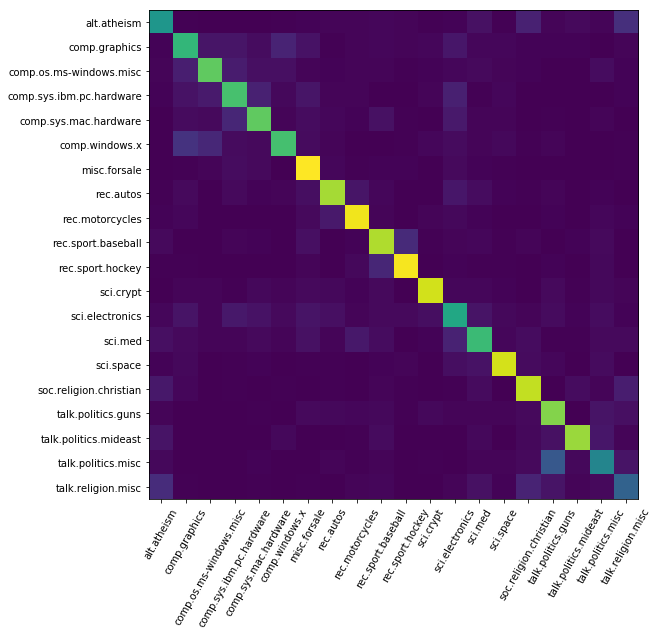

In [9]:
# Grid acha os melhores parâmetros e retreina o modelo
# sobre todo o conjunto de treino usando estes.
# Logo, os métodos `predict` e `score` já estão disponíveis aqui mesmo:
p = grid.predict(test.data)

print(metrics.classification_report(test.target, p))

print('Confusion matrix:')
plt.figure(figsize=(16, 9))
_ = plt.imshow(metrics.confusion_matrix(test.target, p))
_ = plt.yticks(range(len(test.target_names)), test.target_names)
_ = plt.xticks(range(len(test.target_names)), test.target_names, rotation=60)

Seja *a* um artigo sobre *baseball* no conjunto de teste. Com qual probabilidade seu modelo o classificará como efetivamente `rec.sport.baseball`?

recall: 0.73